# 1. Data Acquisition & Preprocessing

This notebook implements the roadmap **through Phase 3** for the UPI project using the
**2022 FIFA World Cup Final** (`match_id = 3869151`) from StatsBomb Open Data.

The preprocessing pipeline follows the roadmap closely:

- fetch event data and StatsBomb 360 freeze-frame tracking data
- keep only **open-play** passes, carries, and shots
- normalize coordinates so the team in possession always attacks from **left to right**
- discretize the pitch into a **16 x 12** grid for Markov/xT modeling

The result is a clean action table that can support contextual EDA and the construction
of a full Expected Threat surface.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mplsoccer import Pitch
from statsbombpy import sb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

match_id = 3869151
pitch_length = 120.0
pitch_width = 80.0
grid_x_bins = 16
grid_y_bins = 12


def is_location(value):
    return isinstance(value, list) and len(value) >= 2


def get_end_location(row):
    if row["type"] == "Pass":
        return row.get("pass_end_location")
    if row["type"] == "Carry":
        return row.get("carry_end_location")
    return None


def infer_attacking_right(group):
    shot_locs = [
        loc[0]
        for loc in group.loc[group["type"] == "Shot", "location"]
        if is_location(loc)
    ]
    if shot_locs:
        return float(np.mean(shot_locs)) >= pitch_length / 2

    move_deltas = []
    for _, row in group[group["type"].isin(["Pass", "Carry"])].iterrows():
        start = row.get("location")
        end = get_end_location(row)
        if is_location(start) and is_location(end):
            move_deltas.append(end[0] - start[0])

    if move_deltas:
        return float(np.mean(move_deltas)) >= 0

    return True


def normalize_location(location, attacking_right):
    if not is_location(location):
        return np.nan
    x, y = float(location[0]), float(location[1])
    if attacking_right:
        return [x, y]
    return [pitch_length - x, pitch_width - y]


def normalize_freeze_frame(frame_list, attacking_right):
    if not isinstance(frame_list, list):
        return np.nan

    normalized = []
    for player in frame_list:
        if not isinstance(player, dict):
            continue
        player_copy = dict(player)
        player_copy["location"] = normalize_location(player.get("location"), attacking_right)
        normalized.append(player_copy)
    return normalized


def get_grid_cell(location):
    if not is_location(location):
        return np.nan, np.nan

    x = min(max(location[0], 0.0), pitch_length - 1e-6)
    y = min(max(location[1], 0.0), pitch_width - 1e-6)
    x_idx = min(int(x / (pitch_length / grid_x_bins)), grid_x_bins - 1)
    y_idx = min(int(y / (pitch_width / grid_y_bins)), grid_y_bins - 1)
    return x_idx, y_idx


print(f"Fetching event data for match_id={match_id}...")
events_df = sb.events(match_id=match_id)

print(f"Fetching 360 freeze frames for match_id={match_id}...")
frames_df = pd.DataFrame(sb.frames(match_id=match_id, fmt="dict"))
frames_df = frames_df.rename(columns={"freeze_frame": "360_frames"})

merge_cols = [col for col in ["event_uuid", "360_frames", "visible_area"] if col in frames_df.columns]
df = events_df.merge(
    frames_df[merge_cols],
    left_on="id",
    right_on="event_uuid",
    how="left",
)

df = df[df["location"].notna()].copy()
df["pass_type"] = df.get("pass_type")
df["shot_type"] = df.get("shot_type")
df["play_pattern"] = df.get("play_pattern")
df["under_pressure"] = df.get("under_pressure", False).fillna(False)

open_play_mask = df["play_pattern"].fillna("Regular Play").eq("Regular Play")
pass_mask = df["type"].eq("Pass") & ~df["pass_type"].fillna("").isin(
    ["Corner", "Free Kick", "Goal Kick", "Kick Off", "Throw-in"]
)
carry_mask = df["type"].eq("Carry")
shot_mask = df["type"].eq("Shot") & ~df["shot_type"].fillna("").isin(["Free Kick", "Penalty"])

events_filtered = df[open_play_mask & (pass_mask | carry_mask | shot_mask)].copy()

attack_direction = {
    (team, period): infer_attacking_right(group)
    for (team, period), group in events_filtered.groupby(["team", "period"])
}

events_filtered["attacking_right"] = events_filtered.apply(
    lambda row: attack_direction.get((row["team"], row["period"]), True),
    axis=1,
)
events_filtered["location_normalized"] = events_filtered.apply(
    lambda row: normalize_location(row["location"], row["attacking_right"]),
    axis=1,
)
events_filtered["end_location_normalized"] = events_filtered.apply(
    lambda row: normalize_location(get_end_location(row), row["attacking_right"]),
    axis=1,
)
events_filtered["360_frames_normalized"] = events_filtered.apply(
    lambda row: normalize_freeze_frame(row.get("360_frames"), row["attacking_right"]),
    axis=1,
)

events_filtered[["start_x_idx", "start_y_idx"]] = pd.DataFrame(
    events_filtered["location_normalized"].apply(get_grid_cell).tolist(),
    index=events_filtered.index,
)
events_filtered[["end_x_idx", "end_y_idx"]] = pd.DataFrame(
    events_filtered["end_location_normalized"].apply(get_grid_cell).tolist(),
    index=events_filtered.index,
)

passes = events_filtered[events_filtered["type"] == "Pass"].copy()
carries = events_filtered[events_filtered["type"] == "Carry"].copy()
shots = events_filtered[events_filtered["type"] == "Shot"].copy()
successful_passes = passes[passes["pass_outcome"].isna()].copy()
successful_moves = pd.concat([successful_passes, carries], ignore_index=True)

phase_1_summary = pd.DataFrame(
    {
        "metric": [
            "Open-play actions",
            "Passes",
            "Successful passes",
            "Carries",
            "Shots",
            "Actions with 360 frame",
        ],
        "value": [
            len(events_filtered),
            len(passes),
            len(successful_passes),
            len(carries),
            len(shots),
            int(events_filtered["360_frames"].notna().sum()),
        ],
    }
)

display(phase_1_summary)
events_filtered[
    [
        "minute",
        "team",
        "player",
        "type",
        "location_normalized",
        "end_location_normalized",
        "start_x_idx",
        "start_y_idx",
        "end_x_idx",
        "end_y_idx",
        "under_pressure",
    ]
].head(10)

Fetching event data for match_id=3869151...
Fetching 360 freeze frames for match_id=3869151...


,metric,value
0,Open-play actions,835
1,Passes,431
2,Successful passes,378
3,Carries,394
4,Shots,10
5,Actions with 360 frame,720


,minute,team,player,type,location_normalized,end_location_normalized,start_x_idx,start_y_idx,end_x_idx,end_y_idx,under_pressure
12,0,Argentina,Enzo Fernandez,Pass,"[8.0, 25.9]","[27.5, 23.4]",1,3,3.0,3.0,False
13,0,Argentina,Lionel Andrés Messi Cuccittini,Pass,"[27.2, 21.5]","[30.2, 13.0]",3,3,4.0,1.0,True
14,0,Argentina,Alejandro Darío Gómez,Pass,"[35.2, 10.5]","[29.1, 4.8]",4,1,3.0,0.0,False
15,0,Argentina,Marcos Javier Acuña,Pass,"[26.4, 2.1]","[16.0, 17.6]",3,0,2.0,2.0,True
16,0,Argentina,Nicolás Hernán Otamendi,Pass,"[14.1, 18.0]","[14.1, 44.5]",1,2,1.0,6.0,False
17,0,Argentina,Cristian Gabriel Romero,Pass,"[15.5, 49.7]","[17.4, 71.1]",2,7,2.0,10.0,False
18,0,Argentina,Nahuel Molina Lucero,Pass,"[17.5, 70.8]","[30.6, 73.7]",2,10,4.0,11.0,False
19,0,Argentina,Rodrigo Javier De Paul,Pass,"[31.0, 74.5]","[57.1, 74.9]",4,11,7.0,11.0,False
25,1,Argentina,Nahuel Molina Lucero,Pass,"[46.1, 71.6]","[64.8, 55.7]",6,10,8.0,8.0,False
26,1,Australia,Aaron Mooy,Pass,"[55.3, 24.4]","[59.1, 0.2]",7,3,7.0,0.0,False


# 2. Exploratory Data Analysis (EDA)

The roadmap asks for three pieces of visual justification before modeling:

1. a **raw spatial event map** that shows how event logs alone miss defensive context
2. a **360 freeze frame** that reveals the nearby spatial pressure around the ball
3. a **passing network**, filtered to the starting XI window, to show team structure

These plots build the case for why a context-aware state-value model is necessary.

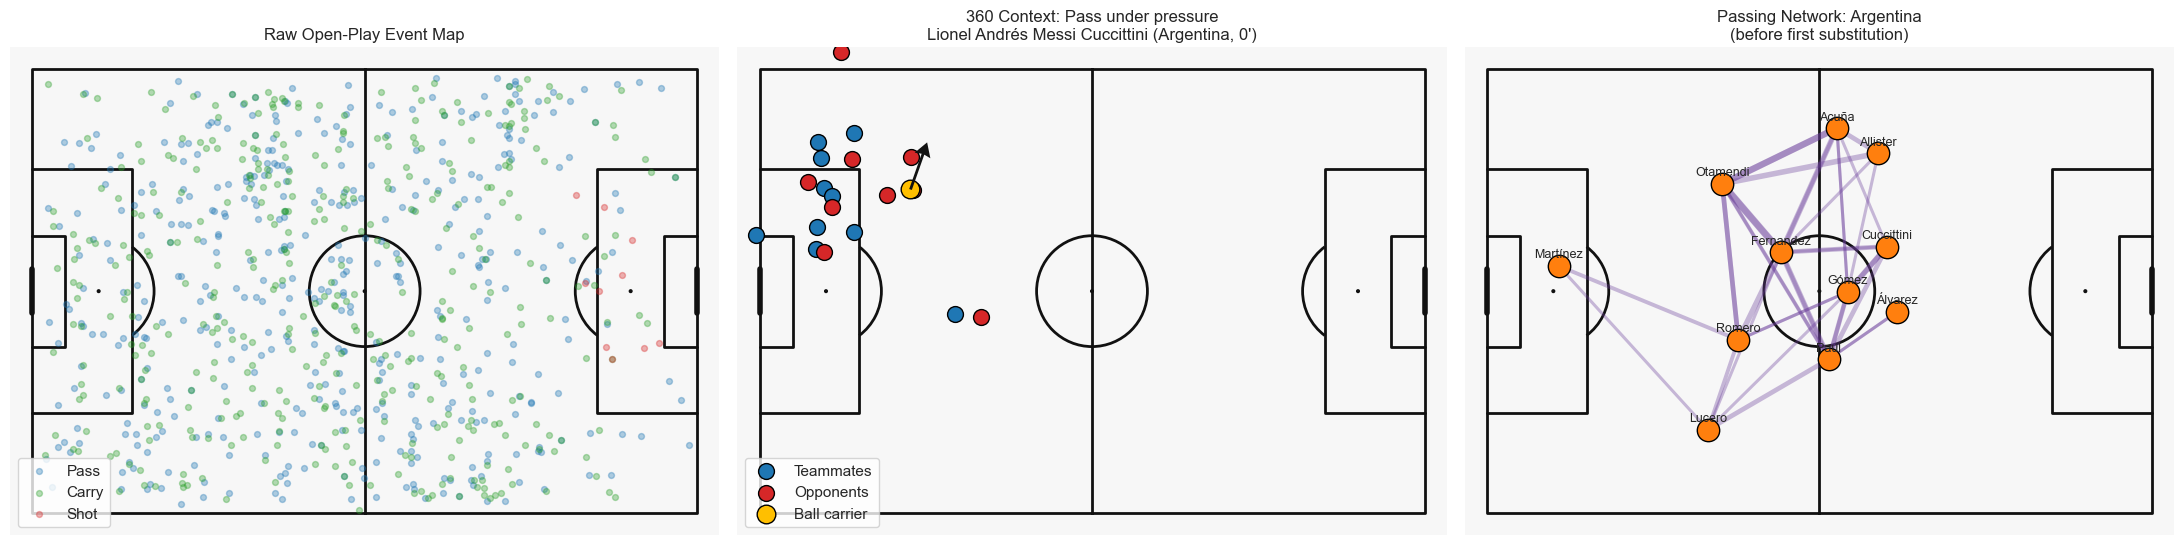

In [2]:
pitch = Pitch(pitch_type="statsbomb", pitch_color="#f7f7f7", line_color="#111111")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# A) Raw spatial event map
pitch.draw(ax=axes[0])
for action_type, color in [("Pass", "#1f77b4"), ("Carry", "#2ca02c"), ("Shot", "#d62728")]:
    sample = events_filtered[events_filtered["type"] == action_type]
    x = [loc[0] for loc in sample["location_normalized"] if is_location(loc)]
    y = [loc[1] for loc in sample["location_normalized"] if is_location(loc)]
    pitch.scatter(x, y, ax=axes[0], s=18, alpha=0.35, color=color, label=action_type)

axes[0].set_title("Raw Open-Play Event Map")
axes[0].legend(loc="lower left")

# B) 360 freeze frame for an action under pressure
pitch.draw(ax=axes[1])
context_actions = events_filtered[
    events_filtered["type"].isin(["Pass", "Carry"])
    & events_filtered["360_frames_normalized"].notna()
].copy()
pressure_actions = context_actions[context_actions["under_pressure"] == True]
sample_action = pressure_actions.iloc[0] if not pressure_actions.empty else context_actions.iloc[0]

frame = sample_action["360_frames_normalized"]
teammates_x, teammates_y, opponents_x, opponents_y = [], [], [], []
for player in frame:
    loc = player.get("location")
    if not is_location(loc):
        continue
    if player.get("teammate"):
        teammates_x.append(loc[0])
        teammates_y.append(loc[1])
    else:
        opponents_x.append(loc[0])
        opponents_y.append(loc[1])

start = sample_action["location_normalized"]
end = sample_action["end_location_normalized"]
pitch.scatter(teammates_x, teammates_y, ax=axes[1], s=130, color="#1f77b4", edgecolors="black", label="Teammates")
pitch.scatter(opponents_x, opponents_y, ax=axes[1], s=130, color="#d62728", edgecolors="black", label="Opponents")
if is_location(start):
    pitch.scatter([start[0]], [start[1]], ax=axes[1], s=180, color="#ffbf00", edgecolors="black", label="Ball carrier")
if is_location(start) and is_location(end):
    pitch.arrows(start[0], start[1], end[0], end[1], ax=axes[1], color="#111111", width=2, headwidth=6)

axes[1].set_title(
    f"360 Context: {sample_action['type']} under pressure\n{sample_action['player']} ({sample_action['team']}, {int(sample_action['minute'])}')"
)
axes[1].legend(loc="lower left")

# C) Passing network until first substitution
pitch.draw(ax=axes[2])
team_for_eda = events_filtered["team"].mode()[0]
subs = events_df[(events_df["type"] == "Substitution") & (events_df["team"] == team_for_eda)]
first_sub_minute = subs["minute"].min() if not subs.empty else 120

network_passes = passes[
    (passes["team"] == team_for_eda)
    & (passes["minute"] < first_sub_minute)
    & (passes["pass_outcome"].isna())
].copy()

if "pass_recipient" in network_passes.columns and not network_passes.empty:
    network_passes["x"] = network_passes["location_normalized"].apply(lambda loc: loc[0] if is_location(loc) else np.nan)
    network_passes["y"] = network_passes["location_normalized"].apply(lambda loc: loc[1] if is_location(loc) else np.nan)

    avg_locations = network_passes.groupby("player")[["x", "y"]].mean()
    pass_links = (
        network_passes.groupby(["player", "pass_recipient"])
        .size()
        .reset_index(name="count")
        .query("count >= 2")
    )

    for _, row in pass_links.iterrows():
        passer = row["player"]
        recipient = row["pass_recipient"]
        if passer in avg_locations.index and recipient in avg_locations.index:
            pitch.lines(
                avg_locations.loc[passer, "x"],
                avg_locations.loc[passer, "y"],
                avg_locations.loc[recipient, "x"],
                avg_locations.loc[recipient, "y"],
                ax=axes[2],
                lw=1 + row["count"] * 0.6,
                color="#6a3d9a",
                alpha=0.35,
                zorder=1,
            )

    pitch.scatter(
        avg_locations["x"],
        avg_locations["y"],
        ax=axes[2],
        s=260,
        color="#ff7f0e",
        edgecolors="black",
        zorder=2,
    )

    for player_name, row in avg_locations.iterrows():
        label = str(player_name).split()[-1]
        pitch.annotate(label, xy=(row["x"], row["y"] - 2), ax=axes[2], ha="center", va="center", fontsize=9)

axes[2].set_title(f"Passing Network: {team_for_eda}\n(before first substitution)")

plt.tight_layout()
plt.show()

# 3. Core Mathematical Modeling (The xT Surface)

We now build the **Expected Threat (xT)** surface using the Markov framework from the roadmap.

For every grid zone we estimate:

- **Shot probability**: how often possession ends with a shot from that zone
- **Goal probability**: how often those shots become goals
- **Move probability**: how often the ball is moved instead of shot
- **Transition matrix**: where successful passes and carries from that zone actually end up

We then solve the linear system:

\[
X = S + MTX
\]

where `S` is the direct scoring probability by zone, `M` is the diagonal matrix of move
probabilities, and `T` is the zone-to-zone transition matrix.

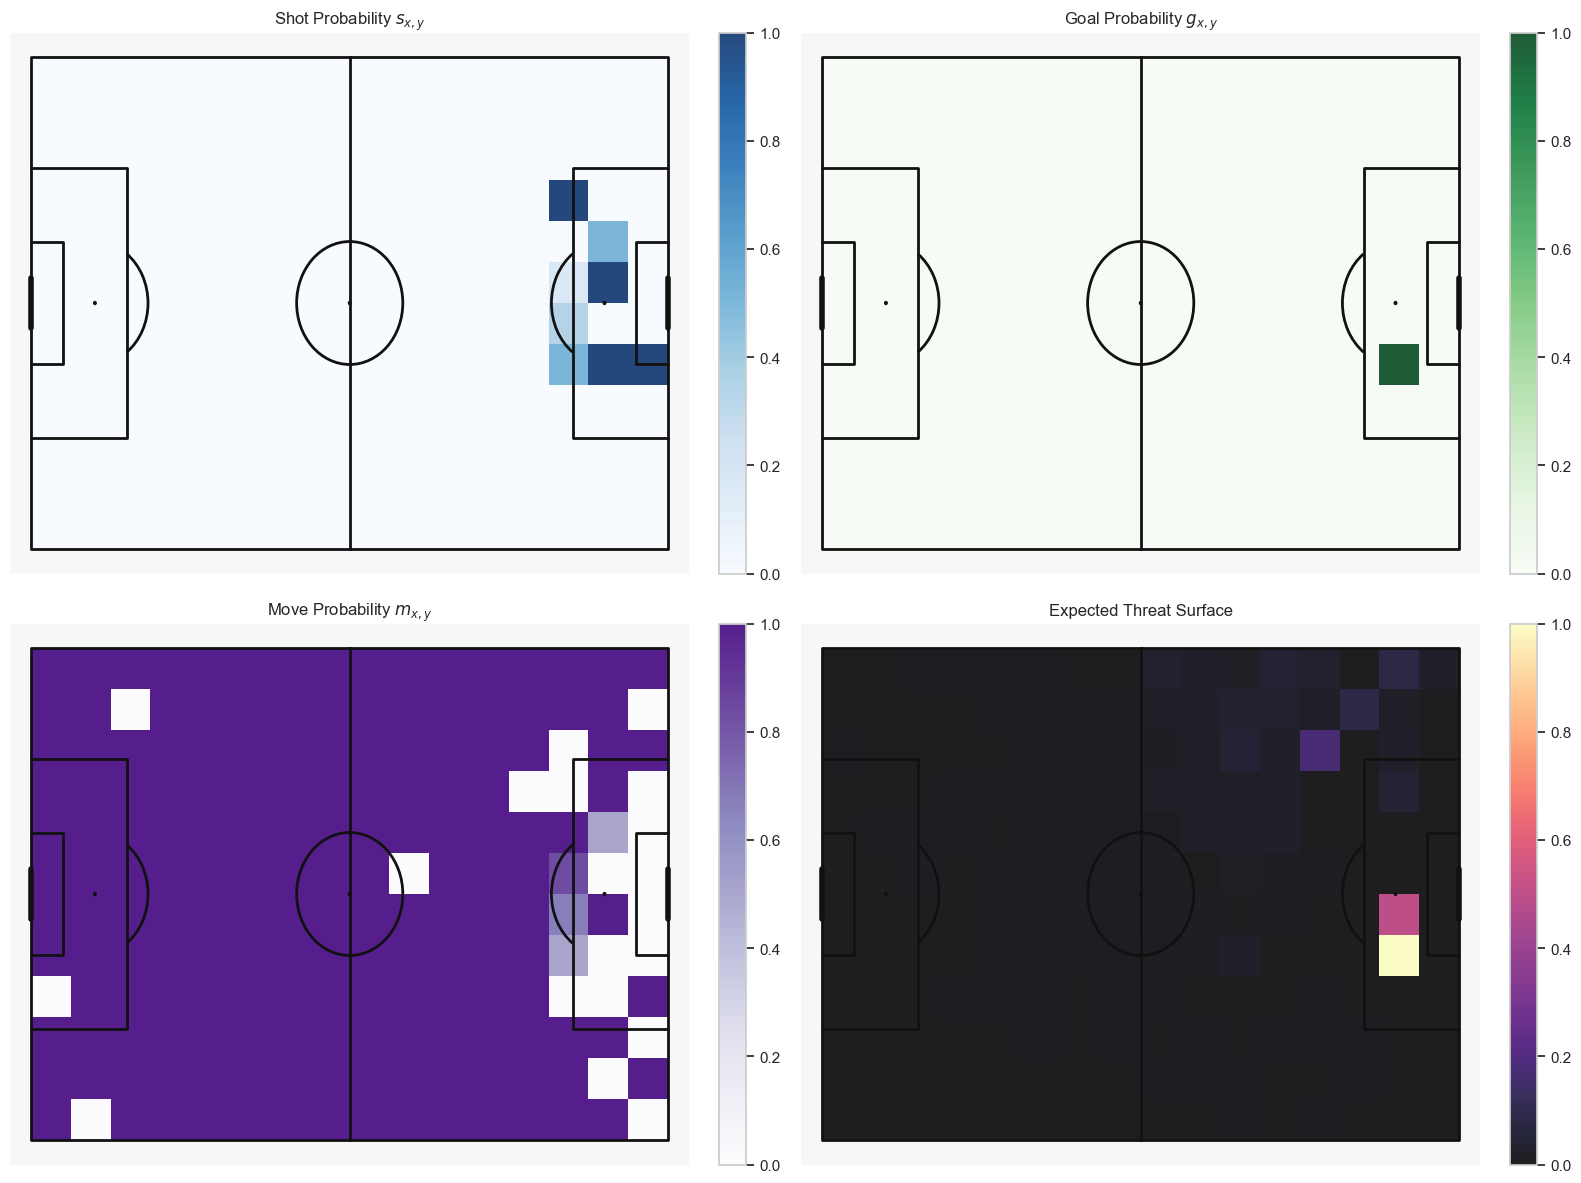

,x_idx,y_idx,shot_prob,goal_prob,move_prob,xT
0,14,7,1.0,1.0,0.0,1.000000
1,14,6,0.0,0.0,1.0,0.500000
2,12,2,0.0,0.0,1.0,0.174946
3,13,1,0.0,0.0,1.0,0.087473
4,14,0,0.0,0.0,1.0,0.087473
5,10,2,0.0,0.0,1.0,0.052655
6,14,3,0.0,0.0,1.0,0.047712
7,11,0,0.0,0.0,1.0,0.044174
8,10,1,0.0,0.0,1.0,0.037487
9,12,0,0.0,0.0,1.0,0.035172


In [3]:
n_zones = grid_x_bins * grid_y_bins

shot_count = np.zeros((grid_x_bins, grid_y_bins))
goal_count = np.zeros((grid_x_bins, grid_y_bins))
move_attempt_count = np.zeros((grid_x_bins, grid_y_bins))
transition_count = np.zeros((n_zones, n_zones))


def flat_zone_index(x_idx, y_idx):
    return int(x_idx) * grid_y_bins + int(y_idx)


for _, event in events_filtered.iterrows():
    sx = event.get("start_x_idx")
    sy = event.get("start_y_idx")
    if pd.isna(sx) or pd.isna(sy):
        continue

    sx = int(sx)
    sy = int(sy)

    if event["type"] == "Shot":
        shot_count[sx, sy] += 1
        if event.get("shot_outcome") == "Goal":
            goal_count[sx, sy] += 1

    elif event["type"] in ["Pass", "Carry"]:
        move_attempt_count[sx, sy] += 1

        ex = event.get("end_x_idx")
        ey = event.get("end_y_idx")
        if pd.isna(ex) or pd.isna(ey):
            continue

        successful_move = event["type"] == "Carry" or pd.isna(event.get("pass_outcome"))
        if not successful_move:
            continue

        start_idx = flat_zone_index(sx, sy)
        end_idx = flat_zone_index(int(ex), int(ey))
        transition_count[start_idx, end_idx] += 1

total_actions = shot_count + move_attempt_count
safe_total_actions = np.where(total_actions == 0, 1, total_actions)
safe_shot_count = np.where(shot_count == 0, 1, shot_count)

s_prob = shot_count / safe_total_actions
g_prob = goal_count / safe_shot_count
m_prob = move_attempt_count / safe_total_actions

S = (s_prob * g_prob).reshape(-1)
move_attempt_vector = move_attempt_count.reshape(-1)
safe_move_attempt_vector = np.where(move_attempt_vector == 0, 1, move_attempt_vector)
T = transition_count / safe_move_attempt_vector[:, np.newaxis]
M = np.diag(m_prob.reshape(-1))

system_matrix = np.eye(n_zones) - (M @ T)
try:
    X = np.linalg.solve(system_matrix, S)
except np.linalg.LinAlgError:
    X = np.linalg.pinv(system_matrix) @ S

xT_surface = X.reshape((grid_x_bins, grid_y_bins))


def plot_zone_surface(ax, surface, title, cmap):
    pitch = Pitch(pitch_type="statsbomb", pitch_color="#f7f7f7", line_color="#111111")
    pitch.draw(ax=ax)
    image = ax.imshow(
        surface.T,
        extent=(0, pitch_length, pitch_width, 0),
        cmap=cmap,
        alpha=0.88,
        aspect="auto",
    )
    ax.set_title(title)
    return image


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
surfaces = [
    (s_prob, "Shot Probability $s_{x,y}$", "Blues"),
    (g_prob, "Goal Probability $g_{x,y}$", "Greens"),
    (m_prob, "Move Probability $m_{x,y}$", "Purples"),
    (xT_surface, "Expected Threat Surface", "magma"),
]

for ax, (surface, title, cmap) in zip(axes.flat, surfaces):
    image = plot_zone_surface(ax, surface, title, cmap)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

zone_summary = (
    pd.DataFrame(
        {
            "x_idx": np.repeat(np.arange(grid_x_bins), grid_y_bins),
            "y_idx": np.tile(np.arange(grid_y_bins), grid_x_bins),
            "shot_prob": s_prob.reshape(-1),
            "goal_prob": g_prob.reshape(-1),
            "move_prob": m_prob.reshape(-1),
            "xT": xT_surface.reshape(-1),
        }
    )
    .sort_values("xT", ascending=False)
    .head(12)
    .reset_index(drop=True)
)

display(zone_summary)

# 4. Action Valuation: Solving the Bias

Phase 4 applies the xT surface to individual actions. For every successful pass and carry,
we calculate:

`xT_added = xT_end - xT_start`

We also add a lightweight pressure multiplier from the 360 freeze frames. When opponents
are close to the ball carrier, a successful progression receives extra credit because the
action was performed in a more difficult spatial context.

,minute,team,player,type,xT_start,xT_end,xT_added,nearby_opponents,pressure_adjusted_xT
0,56,Argentina,Julián Álvarez,Carry,0.500000,1.000000,0.500000,2,0.580000
1,96,Australia,Craig Goodwin,Pass,0.174946,0.500000,0.325054,4,0.429072
2,41,Argentina,Marcos Javier Acuña,Pass,0.044174,0.174946,0.130772,1,0.141233
3,96,Australia,Kye Rowles,Pass,0.052655,0.174946,0.122290,1,0.132074
4,17,Argentina,Lionel Andrés Messi Cuccittini,Carry,0.087473,0.174946,0.087473,2,0.101468
5,17,Argentina,Lionel Andrés Messi Cuccittini,Pass,0.047712,0.087473,0.039760,2,0.046122
6,95,Australia,Mathew Ryan,Pass,0.010435,0.044174,0.033739,1,0.036438
7,17,Argentina,Rodrigo Javier De Paul,Pass,0.025464,0.047712,0.022248,3,0.027588
8,96,Australia,Kye Rowles,Carry,0.028871,0.052655,0.023784,1,0.025687
9,9,Argentina,Enzo Fernandez,Pass,0.022300,0.047712,0.025412,0,0.025412


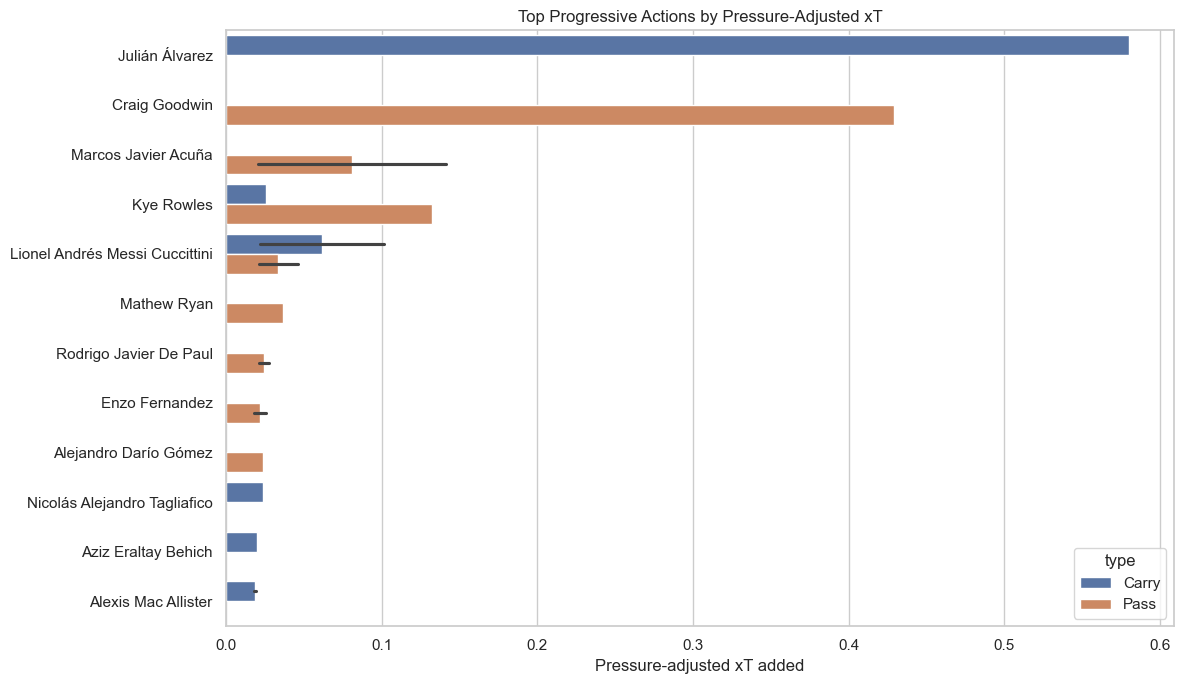

In [4]:
def zone_xt(x_idx, y_idx):
    if pd.isna(x_idx) or pd.isna(y_idx):
        return np.nan
    x_idx = int(x_idx)
    y_idx = int(y_idx)
    if 0 <= x_idx < grid_x_bins and 0 <= y_idx < grid_y_bins:
        return float(xT_surface[x_idx, y_idx])
    return np.nan


def nearby_opponent_count(row, radius=8.0):
    frame = row.get("360_frames_normalized")
    start = row.get("location_normalized")
    if not isinstance(frame, list) or not is_location(start):
        return 0

    count = 0
    for player in frame:
        if player.get("teammate"):
            continue
        loc = player.get("location")
        if is_location(loc) and np.hypot(loc[0] - start[0], loc[1] - start[1]) <= radius:
            count += 1
    return count


action_values = events_filtered[events_filtered["type"].isin(["Pass", "Carry"])].copy()
action_values["successful_action"] = action_values.apply(
    lambda row: row["type"] == "Carry" or pd.isna(row.get("pass_outcome")),
    axis=1,
)
action_values = action_values[action_values["successful_action"]].copy()

action_values["xT_start"] = action_values.apply(
    lambda row: zone_xt(row["start_x_idx"], row["start_y_idx"]),
    axis=1,
)
action_values["xT_end"] = action_values.apply(
    lambda row: zone_xt(row["end_x_idx"], row["end_y_idx"]),
    axis=1,
)
action_values["xT_added"] = action_values["xT_end"] - action_values["xT_start"]
action_values["nearby_opponents"] = action_values.apply(nearby_opponent_count, axis=1)
action_values["pressure_multiplier"] = 1.0 + (0.08 * action_values["nearby_opponents"].clip(upper=5))
action_values["pressure_adjusted_xT"] = action_values["xT_added"] * action_values["pressure_multiplier"]

top_actions = (
    action_values[
        [
            "minute",
            "team",
            "player",
            "type",
            "xT_start",
            "xT_end",
            "xT_added",
            "nearby_opponents",
            "pressure_adjusted_xT",
        ]
    ]
    .sort_values("pressure_adjusted_xT", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

display(top_actions)

fig, ax = plt.subplots(figsize=(12, 7))
plot_actions = action_values.sort_values("pressure_adjusted_xT", ascending=False).head(20)
sns.barplot(data=plot_actions, x="pressure_adjusted_xT", y="player", hue="type", ax=ax)
ax.set_title("Top Progressive Actions by Pressure-Adjusted xT")
ax.set_xlabel("Pressure-adjusted xT added")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# 5. Synthesizing the Unified Performance Index (UPI)

Phase 5 combines multiple contributions into one match-level player score.

Because StatsBomb 360 open data gives freeze-frame locations but not persistent player
identities for every off-ball runner, the off-ball component below is a transparent proxy:
successful recipients get credit for receiving progressive passes in valuable zones.

Components:

- `C_on_ball`: pressure-adjusted xT from passes and carries
- `C_off_ball`: reception-value proxy from progressive received passes
- `C_defensive`: opponent xT mitigated by successful defensive actions
- `C_stability`: pass completion over a simple expected-completion model

,player,C_on_ball,C_off_ball,C_defensive,C_stability,pass_count,UPI_raw,UPI_rating
0,Julián Álvarez,0.601633,0.043494,0.578757,0.117544,10.0,2.272748,10.000000
1,Craig Goodwin,0.428965,0.156285,0.006678,-0.657667,5.0,0.995541,7.834452
2,Marcos Javier Acuña,0.108682,0.092803,0.068526,0.503013,23.0,0.527494,6.971996
3,Mitchell Thomas Duke,-0.033724,0.004520,0.563091,0.057363,6.0,0.457628,6.843255
4,Kye Rowles,0.149200,0.004670,0.040172,0.439621,20.0,0.306804,6.565338
5,Enzo Fernandez,0.022171,0.037877,0.120437,0.616369,38.0,0.263274,6.485126
6,Alexis Mac Allister,0.051520,0.093326,0.103321,0.030464,20.0,0.244889,6.451249
7,Alejandro Darío Gómez,0.015992,0.093238,0.012578,0.543172,17.0,0.220135,6.405637
8,Nicolás Hernán Otamendi,0.024204,0.029833,0.095094,0.637403,37.0,0.215535,6.397159
9,Mathew Ryan,0.047472,0.005258,0.010130,0.648786,15.0,0.081904,6.150922


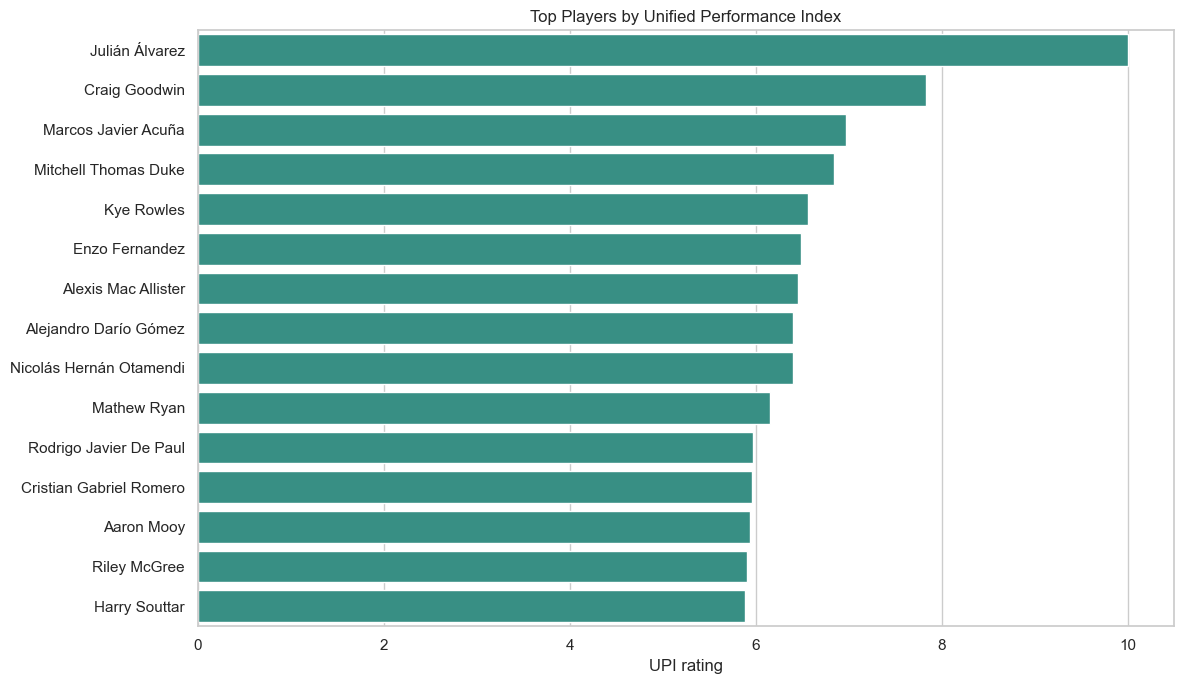

In [5]:
def robust_zscore(series):
    series = series.fillna(0.0).astype(float)
    std = series.std(ddof=0)
    if std == 0 or pd.isna(std):
        return series * 0.0
    return (series - series.mean()) / std


def normalize_against_possession(row):
    team = row.get("possession_team") if pd.notna(row.get("possession_team")) else row.get("team")
    direction = attack_direction.get((team, row.get("period")), True)
    return normalize_location(row.get("location"), direction)


def is_successful_defensive_action(row):
    event_type = row.get("type")
    if event_type in ["Block", "Clearance"]:
        return True
    if event_type == "Ball Recovery":
        return not bool(row.get("ball_recovery_recovery_failure") is True)
    if event_type == "Interception":
        return str(row.get("interception_outcome")) in ["Won", "Success In Play"]
    if event_type == "Duel":
        return str(row.get("duel_outcome")) in ["Won", "Success In Play", "Success Out"]
    return False


on_ball = (
    action_values.groupby("player", dropna=True)["pressure_adjusted_xT"]
    .sum()
    .rename("C_on_ball")
    .reset_index()
)

reception_values = action_values[action_values["type"] == "Pass"].copy()
reception_values["reception_value"] = reception_values["xT_added"].clip(lower=0)
off_ball = (
    reception_values.dropna(subset=["pass_recipient"])
    .groupby("pass_recipient")["reception_value"]
    .sum()
    .rename_axis("player")
    .reset_index()
    .rename(columns={"reception_value": "C_off_ball"})
)

defensive_types = ["Interception", "Duel", "Block", "Ball Recovery", "Clearance"]
defensive_events = df[df["type"].isin(defensive_types) & df["location"].notna()].copy()
defensive_events["location_against_possession"] = defensive_events.apply(normalize_against_possession, axis=1)
defensive_events[["def_x_idx", "def_y_idx"]] = pd.DataFrame(
    defensive_events["location_against_possession"].apply(get_grid_cell).tolist(),
    index=defensive_events.index,
)
defensive_events["successful_defense"] = defensive_events.apply(is_successful_defensive_action, axis=1)
defensive_events["C_defensive_action"] = defensive_events.apply(
    lambda row: zone_xt(row["def_x_idx"], row["def_y_idx"]) if row["successful_defense"] else 0.0,
    axis=1,
)
defensive = (
    defensive_events.groupby("player", dropna=True)["C_defensive_action"]
    .sum()
    .rename("C_defensive")
    .reset_index()
)

pass_model = passes.copy()
pass_model["pass_success"] = pass_model["pass_outcome"].isna().astype(float)
pass_model["pass_length"] = pass_model.apply(
    lambda row: np.hypot(
        row["end_location_normalized"][0] - row["location_normalized"][0],
        row["end_location_normalized"][1] - row["location_normalized"][1],
    )
    if is_location(row.get("location_normalized")) and is_location(row.get("end_location_normalized"))
    else np.nan,
    axis=1,
)
pass_model["expected_completion"] = 1 / (
    1
    + np.exp(
        -(
            2.4
            - 0.055 * pass_model["pass_length"].fillna(pass_model["pass_length"].median())
            - 0.45 * pass_model["under_pressure"].astype(bool).astype(int)
        )
    )
)
stability = (
    pass_model.groupby("player", dropna=True)
    .agg(
        actual_completion=("pass_success", "mean"),
        expected_completion=("expected_completion", "mean"),
        pass_count=("pass_success", "count"),
    )
    .reset_index()
)
stability["C_stability"] = (
    stability["actual_completion"] - stability["expected_completion"]
) * np.log1p(stability["pass_count"])

upi = on_ball.merge(off_ball, on="player", how="outer")
upi = upi.merge(defensive, on="player", how="outer")
upi = upi.merge(stability[["player", "C_stability", "pass_count"]], on="player", how="outer")
for col in ["C_on_ball", "C_off_ball", "C_defensive", "C_stability", "pass_count"]:
    upi[col] = upi[col].fillna(0.0)

upi["UPI_raw"] = (
    0.45 * robust_zscore(upi["C_on_ball"])
    + 0.20 * robust_zscore(upi["C_off_ball"])
    + 0.20 * robust_zscore(upi["C_defensive"])
    + 0.15 * robust_zscore(upi["C_stability"])
)
upi["UPI_rating"] = 6.0 + robust_zscore(upi["UPI_raw"])
upi["UPI_rating"] = upi["UPI_rating"].clip(0, 10)

top_upi = upi.sort_values("UPI_rating", ascending=False).head(15).reset_index(drop=True)
display(top_upi)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(data=top_upi, x="UPI_rating", y="player", ax=ax, color="#2a9d8f")
ax.set_title("Top Players by Unified Performance Index")
ax.set_xlabel("UPI rating")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# 6. Model Validation

Phase 6 checks whether the probability layer behaves sensibly. With one match, this is
a small-sample validation rather than a final academic benchmark, but it gives us the
correct machinery:

- expected goals vs actual goals by team
- Brier score and log loss for shot probabilities
- ROC AUC when both goal and non-goal shots are present
- Monte Carlo bootstrapping of predicted goals

,team,shots,expected_goals,actual_goals,error
0,Argentina,14,1.481579,2,0.518421
1,Australia,5,0.426118,0,-0.426118


,metric,value
0,Brier score,0.088873
1,Log loss,0.301391
2,ROC AUC,0.764706
3,Actual goals,2.000000
4,Bootstrap mean goals,1.856000
5,Bootstrap 5th pct,0.000000
6,Bootstrap 95th pct,4.000000


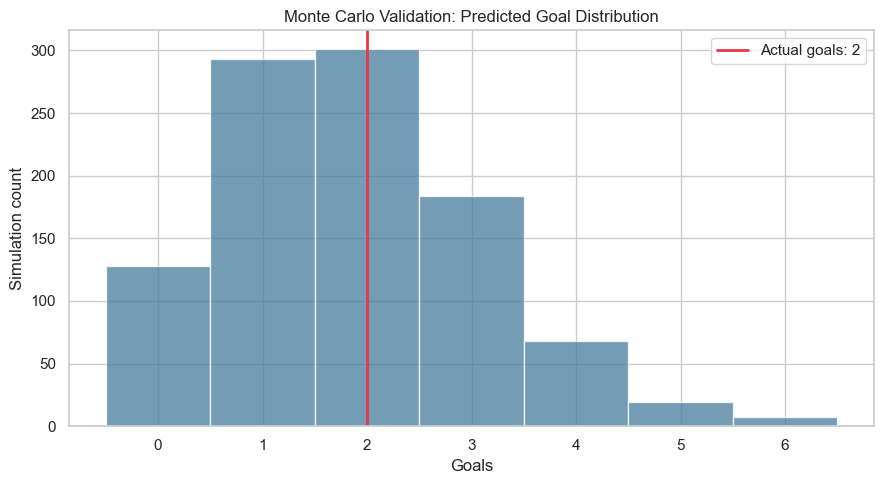

In [6]:
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

validation_shots = events_df[events_df["type"] == "Shot"].copy()
validation_shots["goal"] = validation_shots["shot_outcome"].eq("Goal").astype(int)
validation_shots["model_prob"] = validation_shots["shot_statsbomb_xg"].fillna(
    validation_shots["goal"].mean()
)
validation_shots["model_prob"] = validation_shots["model_prob"].clip(1e-6, 1 - 1e-6)

team_validation = (
    validation_shots.groupby("team")
    .agg(
        shots=("goal", "count"),
        expected_goals=("model_prob", "sum"),
        actual_goals=("goal", "sum"),
    )
    .reset_index()
)
team_validation["error"] = team_validation["actual_goals"] - team_validation["expected_goals"]
display(team_validation)

brier = brier_score_loss(validation_shots["goal"], validation_shots["model_prob"])
logloss = log_loss(validation_shots["goal"], validation_shots["model_prob"])
auc = (
    roc_auc_score(validation_shots["goal"], validation_shots["model_prob"])
    if validation_shots["goal"].nunique() == 2
    else np.nan
)

rng = np.random.default_rng(42)
bootstrap_goals = rng.binomial(1, validation_shots["model_prob"].to_numpy(), size=(1000, len(validation_shots))).sum(axis=1)
actual_goals = int(validation_shots["goal"].sum())
validation_metrics = pd.DataFrame(
    {
        "metric": ["Brier score", "Log loss", "ROC AUC", "Actual goals", "Bootstrap mean goals", "Bootstrap 5th pct", "Bootstrap 95th pct"],
        "value": [
            brier,
            logloss,
            auc,
            actual_goals,
            bootstrap_goals.mean(),
            np.percentile(bootstrap_goals, 5),
            np.percentile(bootstrap_goals, 95),
        ],
    }
)
display(validation_metrics)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(bootstrap_goals, bins=np.arange(bootstrap_goals.min(), bootstrap_goals.max() + 2) - 0.5, color="#457b9d", alpha=0.75)
ax.axvline(actual_goals, color="#e63946", linewidth=2, label=f"Actual goals: {actual_goals}")
ax.set_title("Monte Carlo Validation: Predicted Goal Distribution")
ax.set_xlabel("Goals")
ax.set_ylabel("Simulation count")
ax.legend()
plt.tight_layout()
plt.show()

# 7. Final Conclusion & Case Study

The final phase demonstrates the FIFA Paradox: a player can produce major tactical value
without relying on goals or assists. We select the highest-rated player with zero goals
and zero assists, compare their traditional output to UPI, and visualize their component
profile.

,player,goals,assists,traditional_output_rating,UPI_rating,C_on_ball,C_off_ball,C_defensive,C_stability
0,Craig Goodwin,0,0,6.0,7.834452,0.428965,0.156285,0.006678,-0.657667


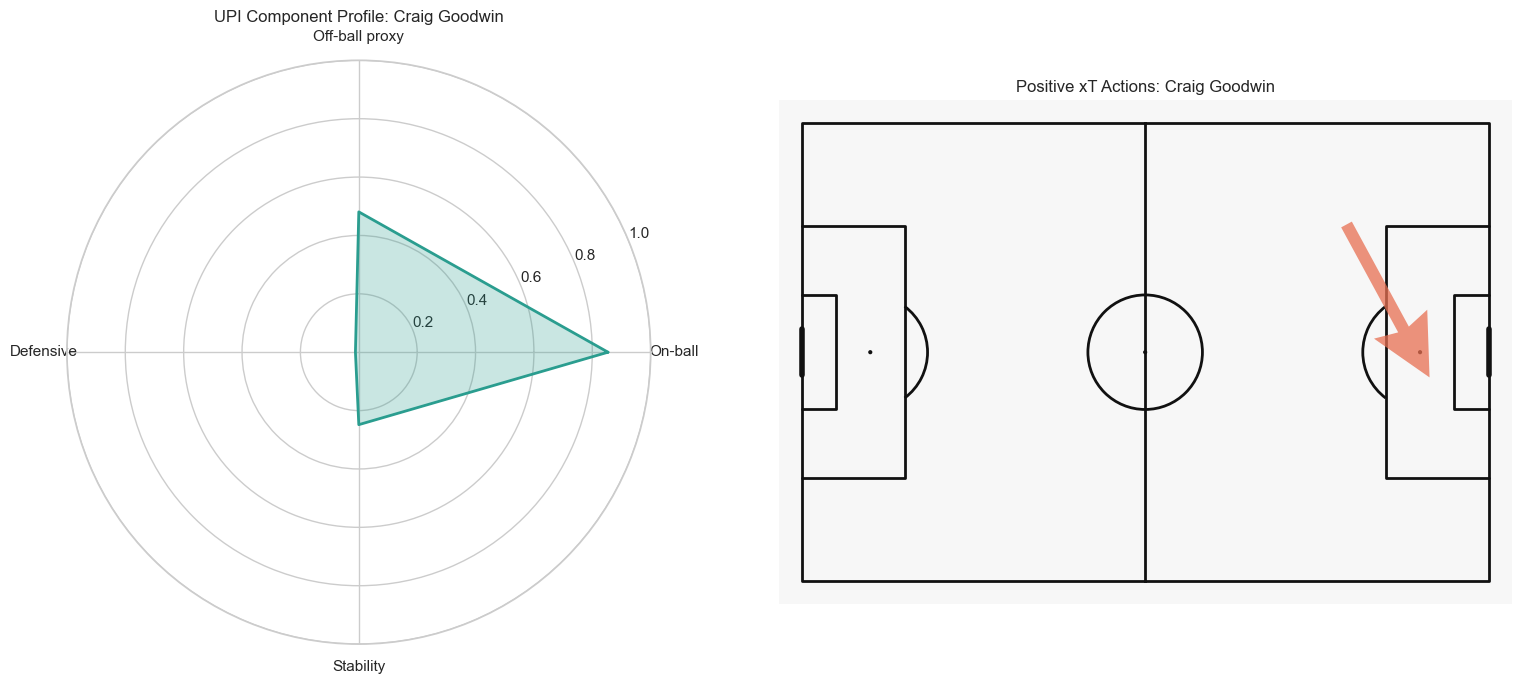

Case study: Craig Goodwin had zero goals and zero assists, but UPI rates them at 7.83 because their tactical value appears in progression, reception value, defensive mitigation, and stability.


In [7]:
goals_by_player = (
    events_df[(events_df["type"] == "Shot") & (events_df["shot_outcome"] == "Goal")]
    .groupby("player")
    .size()
    .rename("goals")
    .reset_index()
)
assists_by_player = (
    events_df[events_df["pass_goal_assist"] == True]
    .groupby("player")
    .size()
    .rename("assists")
    .reset_index()
)

case_pool = upi.merge(goals_by_player, on="player", how="left").merge(assists_by_player, on="player", how="left")
case_pool[["goals", "assists"]] = case_pool[["goals", "assists"]].fillna(0)
case_pool = case_pool[(case_pool["goals"] == 0) & (case_pool["assists"] == 0)].copy()
case_player = case_pool.sort_values("UPI_rating", ascending=False).iloc[0]["player"]
case_row = case_pool[case_pool["player"] == case_player].iloc[0]

traditional_rating = 6.0 + (0.7 * case_row["goals"]) + (0.5 * case_row["assists"])
case_summary = pd.DataFrame(
    {
        "player": [case_player],
        "goals": [int(case_row["goals"])],
        "assists": [int(case_row["assists"])],
        "traditional_output_rating": [traditional_rating],
        "UPI_rating": [case_row["UPI_rating"]],
        "C_on_ball": [case_row["C_on_ball"]],
        "C_off_ball": [case_row["C_off_ball"]],
        "C_defensive": [case_row["C_defensive"]],
        "C_stability": [case_row["C_stability"]],
    }
)
display(case_summary)

component_cols = ["C_on_ball", "C_off_ball", "C_defensive", "C_stability"]
radar_values = []
for col in component_cols:
    col_min = upi[col].min()
    col_max = upi[col].max()
    value = case_row[col]
    radar_values.append(0.0 if col_max == col_min else (value - col_min) / (col_max - col_min))

labels = ["On-ball", "Off-ball proxy", "Defensive", "Stability"]
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
radar_values_closed = radar_values + radar_values[:1]
angles_closed = angles + angles[:1]

fig = plt.figure(figsize=(16, 7))
ax_radar = fig.add_subplot(1, 2, 1, projection="polar")
ax_pitch = fig.add_subplot(1, 2, 2)

ax_radar.plot(angles_closed, radar_values_closed, color="#2a9d8f", linewidth=2)
ax_radar.fill(angles_closed, radar_values_closed, color="#2a9d8f", alpha=0.25)
ax_radar.set_xticks(angles)
ax_radar.set_xticklabels(labels)
ax_radar.set_ylim(0, 1)
ax_radar.set_title(f"UPI Component Profile: {case_player}")

pitch = Pitch(pitch_type="statsbomb", pitch_color="#f7f7f7", line_color="#111111")
pitch.draw(ax=ax_pitch)
player_actions = action_values[action_values["player"] == case_player].copy()
positive_actions = player_actions[player_actions["pressure_adjusted_xT"] > 0]
for _, row in positive_actions.iterrows():
    start = row["location_normalized"]
    end = row["end_location_normalized"]
    if is_location(start) and is_location(end):
        width = 1 + 18 * max(row["pressure_adjusted_xT"], 0)
        pitch.arrows(start[0], start[1], end[0], end[1], ax=ax_pitch, color="#e76f51", width=width, headwidth=5, alpha=0.75)

ax_pitch.set_title(f"Positive xT Actions: {case_player}")
plt.tight_layout()
plt.show()

print(
    f"Case study: {case_player} had zero goals and zero assists, "
    f"but UPI rates them at {case_row['UPI_rating']:.2f} because their tactical value "
    "appears in progression, reception value, defensive mitigation, and stability."
)

## Status

The notebook is now implemented **through Phase 7** of the roadmap:

- Phase 1: data acquisition, open-play filtering, direction normalization, grid assignment
- Phase 2: raw event map, 360 contextual frame, starting-XI passing network
- Phase 3: shot/move/goal probabilities, transition matrix, and solved xT surface
- Phase 4: pass/carry action valuation with pressure adjustment
- Phase 5: match-level UPI synthesis from on-ball, off-ball proxy, defensive, and stability components
- Phase 6: validation against actual goals and StatsBomb xG calibration
- Phase 7: final case study with a radar chart and impact map